# M0 — independent Gaussian copula

This is a self-contained scientific monograph for M0. It assumes no prior notebook. See [the research problem](../../docs/scientific/01_research_problem.md), [finite PIT construction](../../docs/scientific/03_chronos_and_pit.md), and [dependence models](../../docs/scientific/04_dependence_models.md).

## Complete notation and validity

$i$ indexes forecast instance with origin $t^{(i)}$; $g$ indexes a static group $\mathcal E_g=\{k_1,\ldots,k_{K_g}\}$; and $\tau$ is one-based lead. $Y_{k,\tau}^{(i)}$ is random, $y_{k,\tau}^{(i)}$ is observed, and $F_{k,\tau}^{(i)}$ is its fixed marginal forecast. $A_{g,\tau}^{(i)}=\sum_kY_{k,\tau}^{(i)}$ is the random aggregate.

$V_{k,\tau}^{(i)}=1$ means entity $k$ has a finite observation and valid marginal grid. The complete-group indicator is $V_{g,\tau}^{(i)}=\prod_{k\in\mathcal E_g}V_{k,\tau}^{(i)}$. M0 is evaluated only if $V_g=1$; it never removes an invalid entity.

## Statistical hypothesis

M0 asserts conditional rank independence, not independence of physical loads:
$$C_{g,\tau}^{(i)}(u_1,\ldots,u_{K_g})=\prod_{k=1}^{K_g}u_k,\qquad R_{g,\tau}^{(i)}=I_{K_g}.$$
Draw $\eta^{(m)}\sim\mathcal N(0,I_{K_g})$ and set $U_k^{(m)}=\Phi(\eta_k^{(m)})$. The components are independent uniforms. Projecting them to each fixed marginal and summing yields $\widetilde A^{(m)}=\sum_k\widetilde Y_k^{(m)}$. M0 therefore asks what aggregate uncertainty would remain if residual ranks had no spatial dependence.

In [2]:
from pathlib import Path
import sys, numpy as np, matplotlib.pyplot as plt, torch
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'pyproject.toml').is_file())
CACHE_ROOT=PROJECT_ROOT/'artifacts'/'cache'
if str(PROJECT_ROOT / 'src') not in sys.path: sys.path.insert(0, str(PROJECT_ROOT / 'src'))
from simcast.config import load_base_config, load_method_config, resolve_run_config
from simcast.experiments import locate_compatible_cache
from simcast.fm.cache import load_pit_library
from simcast.fm.pit import dependence_pit_scores
from simcast.sampling.gaussian_copula import generate_scenarios
from simcast.cli.train_dependence import train_from_config
from simcast.cli.evaluate import evaluate_from_config
BASE_FILE='configs/bases/liander2024/solar_park.yaml'
METHOD_FILE='configs/methods/m0_independent.yaml'
BASE_OVERRIDES=(f'output.cache_dir={CACHE_ROOT}',); METHOD_OVERRIDES=()
FIT_IF_MISSING=False; RUN_EVALUATION=False  # Used by the final optional computation cell.
RUN_DIR=PROJECT_ROOT/'runs'/'notebook_walkthrough'/'m0_independent'
base=load_base_config(PROJECT_ROOT/BASE_FILE,overrides=BASE_OVERRIDES)
method=load_method_config(PROJECT_ROOT/METHOD_FILE,overrides=METHOD_OVERRIDES)
config=resolve_run_config(base,method)
cache_dir=locate_compatible_cache(base)
library=load_pit_library(cache_dir,access='training'); ds=library.dataset
entity_ids=[str(x) for x in ds.entity_id.values]; K_g=len(entity_ids)
print({'g':base.data.entity_type,'K_g':K_g,'entities':entity_ids,'method':method.id})


{'g': 'solar_park', 'K_g': 5, 'entities': ['solar_park::Within 5 kilometers of Leeuwarden_normalized', 'solar_park::Within 15 kilometers of Oosterwolde_normalized', 'solar_park::Within 15 kilometers of Zutphen_normalized', 'solar_park::Within 20 kilometers of Rotterdam_normalized', 'solar_park::Within 10 kilometers of Westwoud_normalized'], 'method': 'm0'}


## Correlation and aggregate consequence

For two components with marginal variances $\sigma_1^2,\sigma_2^2$, $\mathrm{Var}(Y_1+Y_2)=\sigma_1^2+\sigma_2^2+2\mathrm{Cov}(Y_1,Y_2)$. M0 removes the residual-rank covariance term. If residual ranks are positively associated, M0 commonly understates aggregate dispersion even though every entity marginal is correct.

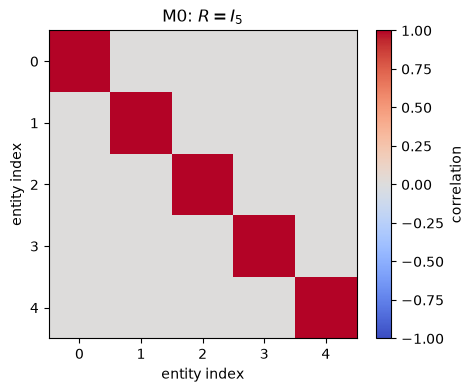

In [3]:
R=np.eye(K_g)
fig,ax=plt.subplots(figsize=(5,4)); im=ax.imshow(R,vmin=-1,vmax=1,cmap='coolwarm')
ax.set(title=fr'M0: $R=I_{{{K_g}}}$',xlabel='entity index',ylabel='entity index'); fig.colorbar(im,ax=ax,label='correlation'); plt.show()


## Observed dependence that M0 deliberately removes

The historical pseudo-PIT $u_{k,\tau}^{(i)}$ locates the observation within its frozen marginal forecast. The configured dependence transform maps it to a Gaussian score $z_{k,\tau}^{(i)}$. Under M0, the corresponding scenario-generating scores are instead independent standard normal variables,
$$X_{g,\tau}^{(i,m)}\sim\mathcal N(\mathbf 0,I_{K_g}).$$
The panels below compare these two objects for the pair of entities having the largest absolute empirical training-score correlation. Pair selection makes the contrast visible; it is descriptive only and does not enter M0. The axes have the same scale, and the same number of independent draws is used as observed complete training cases.

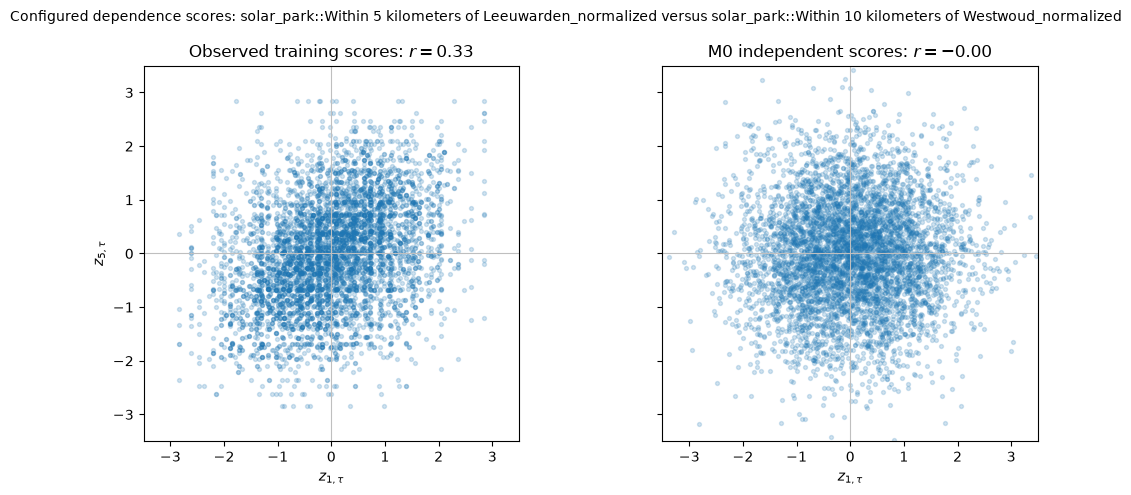

{'dependence_transform': 'training_frequency',
 'complete_training_cases': 21312,
 'displayed_pair': ['solar_park::Within 5 kilometers of Leeuwarden_normalized',
  'solar_park::Within 10 kilometers of Westwoud_normalized'],
 'observed_correlation': 0.32819151717465705}

In [4]:
split=np.asarray(ds['split'].values); training=split=='train'
scores,_=dependence_pit_scores(torch.tensor(np.asarray(ds['pit_u'].values).copy()),torch.tensor(np.asarray(ds['pit_z'].values).copy()),torch.tensor(training.copy()),torch.tensor(np.asarray(ds['quantile'].values).copy()),mode=config.pit.dependence_transform,eps=config.pit.eps)
case_scores=scores.numpy()[training].transpose(0,2,1).reshape(-1,K_g)
case_scores=case_scores[np.isfinite(case_scores).all(axis=1)]
if len(case_scores)<2: raise ValueError('At least two complete training cases are required for this visualization.')
observed_R=np.corrcoef(case_scores,rowvar=False); strength=np.abs(observed_R); np.fill_diagonal(strength,-np.inf); strength[~np.isfinite(strength)]=-np.inf
if not np.isfinite(strength).any(): raise ValueError('No finite cross-entity training correlation is available.')
entity_a,entity_b=map(int,np.unravel_index(np.argmax(strength),strength.shape))
generator=torch.Generator().manual_seed(config.sampling.evaluation_seed)
m0_scores=torch.randn((len(case_scores),2),generator=generator).numpy()
step=max(1,len(case_scores)//5000); observed_pair=case_scores[::step,[entity_a,entity_b]]; m0_pair=m0_scores[::step]
limit=max(3.5,float(np.nanpercentile(np.abs(np.vstack((observed_pair,m0_pair))),99.5)))
fig,axes=plt.subplots(1,2,figsize=(11,5),sharex=True,sharey=True)
panels=((observed_pair,fr'Observed training scores: $r={observed_R[entity_a,entity_b]:.2f}$'),(m0_pair,fr'M0 independent scores: $r={np.corrcoef(m0_scores,rowvar=False)[0,1]:.2f}$'))
for ax,(points,title) in zip(axes,panels):
    ax.scatter(points[:,0],points[:,1],s=8,alpha=.2); ax.axhline(0,color='0.75',lw=.8); ax.axvline(0,color='0.75',lw=.8); ax.set(xlim=(-limit,limit),ylim=(-limit,limit),aspect='equal',title=title,xlabel=fr'$z_{{{entity_a+1},\tau}}$')
axes[0].set_ylabel(fr'$z_{{{entity_b+1},\tau}}$'); fig.suptitle(f'Configured dependence scores: {entity_ids[entity_a]} versus {entity_ids[entity_b]}',fontsize=10); plt.tight_layout(); plt.show()
{'dependence_transform':config.pit.dependence_transform,'complete_training_cases':len(case_scores),'displayed_pair':[entity_ids[entity_a],entity_ids[entity_b]],'observed_correlation':float(observed_R[entity_a,entity_b])}


## From independent ranks to physical and aggregate scenarios

For one valid cached forecast case, M0 first draws $K_g$ mutually independent Gaussian scores $X_k^{(m)}$. Their probability-scale values $U_k^{(m)}=\Phi(X_k^{(m)})$ are independent uniforms. The configured finite-quantile inverse marginal law then produces
$$\widetilde Y_{k,\tau}^{(i,m)}=(\widehat F_{k,\tau}^{(i)})^{-1}(U_k^{(m)}),\qquad \widetilde A_{g,\tau}^{(i,m)}=\sum_{k\in\mathcal E_g}\widetilde Y_{k,\tau}^{(i,m)}.$$
The first panel verifies independence in probability space. The second shows that the physical-scale cloud need not look Gaussian because each axis follows its own frozen Chronos-derived marginal. The third is the induced distribution of the spatial aggregate. The same Monte Carlo draws underlie all three panels.

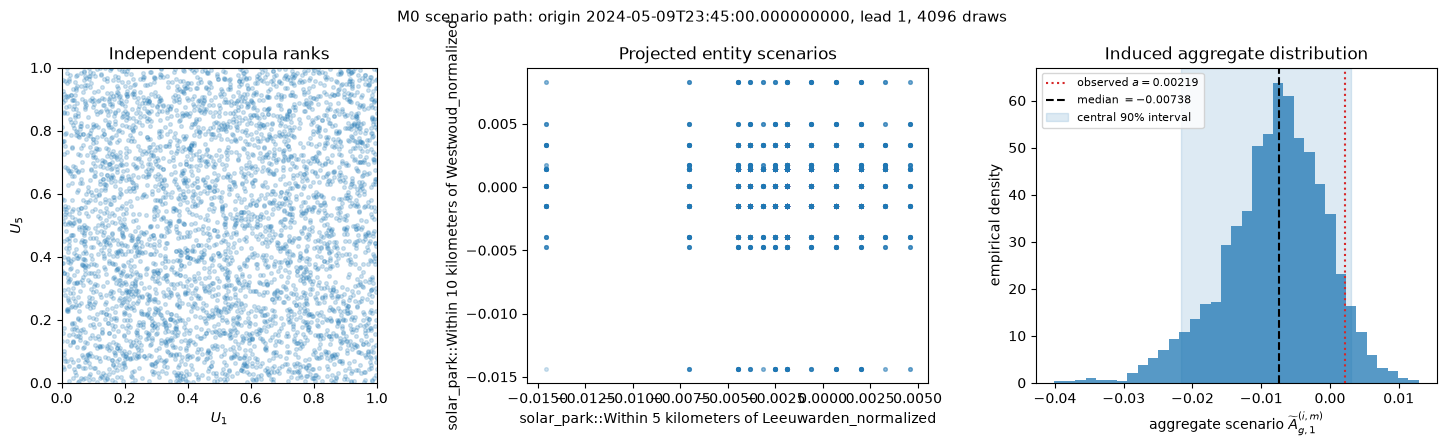

{'origin': '2024-05-09T23:45:00.000000000',
 'lead': 1,
 'marginal_projection': 'discretized',
 'probability_scale_correlation': 0.01907292046289915,
 'aggregate_median': -0.007383760064840317,
 'aggregate_central_90_percent': [-0.02162754535675049, 0.0029901027446612716],
 'observed_aggregate': 0.00219058059155941}

In [5]:
valid=(training[:,None] & np.asarray(ds['pit_valid'].values,dtype=bool)); candidates=np.argwhere(valid)
if candidates.size==0: raise ValueError('The cache contains no valid training case for scenario visualization.')
origin_index,lead_index=map(int,candidates[len(candidates)//2]); lead_value=int(ds['lead'].values[lead_index])
quantile_grid=torch.tensor(np.asarray(ds['quantile_prediction'].values[origin_index,:,lead_index,:]).copy(),dtype=torch.float32)
levels=torch.tensor(np.asarray(ds['quantile'].values).copy(),dtype=torch.float32); R_tensor=torch.eye(K_g,dtype=torch.float32)
generator=torch.Generator().manual_seed(config.sampling.evaluation_seed)
scenarios=generate_scenarios(R_tensor,quantile_grid,levels,num_samples=config.sampling.num_samples,generator=generator,marginal_mode=config.pit.mode)
u=scenarios.uniforms.numpy(); y=scenarios.entity_samples.numpy(); aggregate=scenarios.aggregate_samples.numpy()
observed_aggregate=float(np.asarray(ds['true_y'].values)[origin_index,:,lead_index].sum()); q05,q50,q95=np.quantile(aggregate,[.05,.5,.95])
fig,axes=plt.subplots(1,3,figsize=(15,4.5))
axes[0].scatter(u[:,entity_a],u[:,entity_b],s=7,alpha=.2); axes[0].set(xlim=(0,1),ylim=(0,1),aspect='equal',xlabel=fr'$U_{{{entity_a+1}}}$',ylabel=fr'$U_{{{entity_b+1}}}$',title='Independent copula ranks')
axes[1].scatter(y[:,entity_a],y[:,entity_b],s=7,alpha=.2); axes[1].set(xlabel=entity_ids[entity_a],ylabel=entity_ids[entity_b],title='Projected entity scenarios')
axes[2].hist(aggregate,bins=35,density=True,alpha=.75); axes[2].axvline(observed_aggregate,color='C3',ls=':',label=fr'observed $a={observed_aggregate:.3g}$'); axes[2].axvline(q50,color='black',ls='--',label=fr'median $={q50:.3g}$'); axes[2].axvspan(q05,q95,color='C0',alpha=.15,label='central 90% interval'); axes[2].set(xlabel=fr'aggregate scenario $\widetilde A_{{g,{lead_value}}}^{{(i,m)}}$',ylabel='empirical density',title='Induced aggregate distribution'); axes[2].legend(fontsize=8)
origin_label=str(ds['origin_timestamp'].values[origin_index]); fig.suptitle(f'M0 scenario path: origin {origin_label}, lead {lead_value}, {config.sampling.num_samples} draws',fontsize=11); plt.tight_layout(); plt.show()
{'origin':origin_label,'lead':lead_value,'marginal_projection':config.pit.mode,'probability_scale_correlation':float(np.corrcoef(u[:,entity_a],u[:,entity_b])[0,1]),'aggregate_median':float(q50),'aggregate_central_90_percent':[float(q05),float(q95)],'observed_aggregate':observed_aggregate}


## Optional authoritative computation

`FIT_IF_MISSING` controls whether the following cell records the M0 identity model when it is absent from `RUN_DIR`; no numerical optimization occurs. `RUN_EVALUATION` controls whether sealed test labels are opened and evaluation results are written. Both operations call the same functions as the CLI, so enable them only for a deliberately named analysis directory.

In [3]:
if FIT_IF_MISSING and not (RUN_DIR/'model.npz').is_file():
    train_from_config(config,cache_dir=cache_dir,output_dir=RUN_DIR)
if RUN_EVALUATION:
    evaluate_from_config(config,methods=('independent',),method_runs={'independent':RUN_DIR},cache_dir=cache_dir,output_dir=RUN_DIR/'evaluation')


FileExistsError: [Errno 17] File exists: '/home/kbolat/Python/simcast/runs/notebook_walkthrough/m0_independent/evaluation'

## Interpretation and controls

M0 has no fitted hyperparameters: its complete method file contains only `kind`, `id`, and `family: independent`. In the base file, `sampling.num_samples` determines Monte Carlo resolution, `sampling.common_random_numbers` makes comparisons paired, and `evaluation.*` defines scores. `IndependentCopula` returns $I_{K_g}$ and the Gaussian-copula sampler generates joint ranks. Poor M0 aggregate calibration is evidence of residual spatial dependence, not a causal claim.